# Benchmark CNN Models - UNSW-NB15 to Synthetic IPv6

Prior CNN architectures trained on UNSW-NB15 and evaluated on synthetic IPv6 for transfer comparison.


In [ ]:
import json
import random
import zipfile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
from torchvision import models

GLOBAL_SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(GLOBAL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUT_ROOT = Path("cnn_benchmark_artifacts")
for base in [OUT_ROOT / "unsw" / "binary",
             OUT_ROOT / "unsw" / "multiclass",
             OUT_ROOT / "synthetic_transfer" / "binary",
             OUT_ROOT / "synthetic_transfer" / "multiclass",
             OUT_ROOT / "combined"]:
    base.mkdir(parents=True, exist_ok=True)

USE_HF_DOWNLOAD = False
UNSW_TRAIN_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"
UNSW_TEST_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"


SYN_ROOT = "/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v3_32x32"

CNN_SEEDS = [11, 22, 33, 44, 55]
VAL_SIZE = 0.15
EPOCHS_1D = 15
EPOCHS_IMG = 20
PATIENCE = 4
UNSTABLE_SUPPORT_THRESHOLD = 5

MODEL_NAMES = [
    "systems2024_arch1_1dcnn",
    "systems2024_arch2_1dcnn",
    "noever2021_mobilenetv2_image",
]


Device: cuda


## Dataset Loading

UNSW-NB15 official split and synthetic IPv6 train/validation/test split files.


In [3]:
if USE_HF_DOWNLOAD:
    from huggingface_hub import hf_hub_download
    HF_REPO = "Mouwiya/UNSW-NB15-small"
    UNSW_TRAIN_CSV = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_training-set.csv", repo_type="dataset")
    UNSW_TEST_CSV  = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_testing-set.csv",  repo_type="dataset")

unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
unsw_test  = pd.read_csv(UNSW_TEST_CSV)

syn_flows = pd.read_csv(f"{SYN_ROOT}/flows.csv")
syn_train_split = pd.read_csv(f"{SYN_ROOT}/train.csv")
syn_val_split   = pd.read_csv(f"{SYN_ROOT}/val.csv")
syn_test_split  = pd.read_csv(f"{SYN_ROOT}/test.csv")

syn_train = syn_flows.merge(syn_train_split[["record_id"]], on="record_id", how="inner")
syn_val   = syn_flows.merge(syn_val_split[["record_id"]],   on="record_id", how="inner")
syn_test  = syn_flows.merge(syn_test_split[["record_id"]],  on="record_id", how="inner")

print("UNSW:", unsw_train.shape, unsw_test.shape)
print("Synthetic:", len(syn_train), len(syn_val), len(syn_test), "total:", len(syn_flows))
display(unsw_train.head(2))
display(syn_flows.head(2))


UNSW: (82332, 45) (175341, 45)
Synthetic: 2100 450 450 total: 3000


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0


,record_id,label,window_start_utc,window_end_utc,ip_version,src_ip,dst_ip,src_port,dst_port,transport,...,tcp_ack,tcp_fin,tcp_rst,ipv6_flow_label,ipv6_next_header,ipv6_hop_limit,ipv6_ext_hdr_count,ipv6_fragment_count,icmpv6_nd_msgs,payload_entropy
0,R0000001,Benign,2026-01-01T03:42:04+00:00,2026-01-01T03:42:04.265000+00:00,6,2001:db8:1:ae00:2f8c:83e5:6e8d:9644,2001:db8:1:614c:a921:cb4c:95fb:e976,51628,80,TCP,...,4,0,0,172046,6,122,2,1,0,3.475082
1,R0000002,Benign,2026-01-01T03:10:48+00:00,2026-01-01T03:10:48.243000+00:00,6,2001:db8:1:5111:63be:441d:bd5a:c9e,2001:db8:117:6de2:1b46:ebdc:5c56:d9bc,62821,443,UDP,...,0,0,0,214394,17,132,1,1,1,4.974224


## Helpers


In [4]:
def normalize_attack_name(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    if s.lower() == "normal":
        return "Benign"
    return s

def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))

def save_text(text, path):
    Path(path).write_text(str(text))

def support_flag_table(labels, threshold=5):
    vc = pd.Series(labels).value_counts().sort_values(ascending=True)
    out = vc.rename_axis("label").reset_index(name="support")
    out["unstable"] = out["support"] < threshold
    return out

def plot_bar(series, title, xlabel, ylabel, save_path, top_k=None):
    s = series.copy()
    if top_k is not None:
        s = s.head(top_k)
    plt.figure(figsize=(10, 4))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_confusion(cm, labels, title, save_path, max_labels=20):
    show_labels = labels[:max_labels]
    show_cm = np.array(cm)[:max_labels, :max_labels]
    plt.figure(figsize=(8, 6))
    plt.imshow(show_cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    ticks = np.arange(len(show_labels))
    plt.xticks(ticks, show_labels, rotation=45, ha="right")
    plt.yticks(ticks, show_labels)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_curves(history, prefix, save_dir):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.title("Training loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_train_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.plot(epochs, history["val_macro_f1"], label="val_macro_f1")
    plt.title("Validation metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_val_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()

def multiclass_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=labels, zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4)
    return {
        "accuracy": float(acc),
        "macro_precision": float(p_macro),
        "macro_recall": float(r_macro),
        "macro_f1": float(f1_macro),
        "weighted_f1": float(f1_weighted),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }

def binary_metrics(y_true, y_pred, positive_label="Attack"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=positive_label, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=["Benign", "Attack"])
    report = classification_report(y_true, y_pred, labels=["Benign", "Attack"], digits=4, zero_division=0)
    return {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }

def choose_binary_threshold_from_val(scores, y_val):
    y01 = (pd.Series(y_val) == "Attack").astype(int).values
    prec, rec, thr = precision_recall_curve(y01, scores)
    f1 = (2 * prec * rec) / np.clip(prec + rec, 1e-8, None)
    if len(thr) == 0:
        return 0.5, prec, rec, thr
    best_idx = int(np.nanargmax(f1[:-1]))
    return float(thr[best_idx]), prec, rec, thr

def make_model_dirs(root_base, task, model_name):
    d = root_base / task / model_name
    for sub in ["figures", "tables", "metrics", "reports", "models"]:
        (d / sub).mkdir(parents=True, exist_ok=True)
    return d


## Task Preparation


In [5]:
def prepare_unsw_task(task="multiclass"):
    tr = unsw_train.copy()
    te = unsw_test.copy()

    if task == "multiclass":
        target = "attack_cat"
        tr[target] = tr[target].apply(normalize_attack_name)
        te[target] = te[target].apply(normalize_attack_name)
        drop_cols = ["id", "label"]
        labels = sorted(pd.Series(tr[target]).unique().tolist())
    else:
        target = "label"
        tr[target] = tr[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        te[target] = te[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        drop_cols = ["id", "attack_cat"]
        labels = ["Benign", "Attack"]

    X_pool = tr.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_pool = tr[target].astype(str).values
    X_test = te.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_test = te[target].astype(str).values

    return X_pool, y_pool, X_test, y_test, labels

def prepare_synthetic_eval(task="multiclass"):
    te = syn_test.copy()
    if task == "multiclass":
        te["label"] = te["label"].astype(str).apply(lambda s: "Benign" if s.lower() == "normal" else s)
        labels = sorted(pd.Series(te["label"]).unique().tolist())
    else:
        te["label"] = te["label"].astype(str).map(lambda x: "Benign" if x == "Benign" else "Attack")
        labels = ["Benign", "Attack"]

    X_test = te.drop(columns=["label", "record_id", "window_start_utc", "window_end_utc", "src_ip", "dst_ip"], errors="ignore")
    y_test = te["label"].astype(str).values
    return X_test.reset_index(drop=True), y_test, labels


## Vectorizers

Dense one-hot tabular vectors for 1D CNNs and 16x16 grayscale thumbnails for MobileNetV2.


In [6]:
def _align_to_expected_columns(X, expected_cols):
    """
    Align any dataframe to the schema used during fitting.
    This prevents transfer-time crashes when the synthetic IPv6 dataset
    has different feature columns from UNSW-NB15.
    """
    X_aligned = pd.DataFrame(X).copy()
    expected_cols = list(expected_cols)

    for col in expected_cols:
        if col not in X_aligned.columns:
            X_aligned[col] = np.nan

    return X_aligned.reindex(columns=expected_cols)


def _make_one_hot_encoder(**kwargs):
    """
    Small compatibility wrapper for newer and older scikit-learn versions.
    New versions use sparse_output; older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, **kwargs)


def fit_tabular_vectorizer(X_train):
    X_train = pd.DataFrame(X_train).copy()
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    vec = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler(with_mean=True)),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", _make_one_hot_encoder()),
            ]), cat_cols),
        ],
        remainder="drop"
    )
    vec.fit(X_train)

    vec.expected_input_columns_ = list(X_train.columns)
    return vec


def fit_image_vectorizer(X_train):
    X_train = pd.DataFrame(X_train).copy()
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    ohe = _make_one_hot_encoder()
    if len(cat_cols) > 0:
        ohe.fit(X_train[cat_cols].fillna("<UNK>").astype(str))
        categories = [list(c) for c in ohe.categories_]
    else:
        categories = []

    num_df = X_train[num_cols].apply(pd.to_numeric, errors="coerce")
    num_min = num_df.min()
    num_max = num_df.max()

    return {
        "input_columns": list(X_train.columns),
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "categories": categories,
        "num_min": num_min.to_dict(),
        "num_max": num_max.to_dict(),
    }


def transform_with_tabular_vectorizer(vec, X):
    expected_cols = getattr(vec, "expected_input_columns_", None)
    if expected_cols is None:
        expected_cols = getattr(vec, "feature_names_in_", pd.DataFrame(X).columns)

    X_safe = _align_to_expected_columns(X, expected_cols)
    return vec.transform(X_safe).astype(np.float32)


def transform_with_image_vectorizer(bundle, X):
    expected_cols = bundle.get("input_columns", bundle.get("cat_cols", []) + bundle.get("num_cols", []))
    X_safe = _align_to_expected_columns(X, expected_cols)

    cat_cols = bundle["cat_cols"]
    num_cols = bundle["num_cols"]

    if len(cat_cols) > 0:
        ohe = _make_one_hot_encoder(categories=bundle["categories"])
        dummy = pd.DataFrame({c: [cats[0]] for c, cats in zip(cat_cols, bundle["categories"])})
        ohe.fit(dummy)
        X_cat = ohe.transform(X_safe[cat_cols].fillna("<UNK>").astype(str))
    else:
        X_cat = np.zeros((len(X_safe), 0), dtype=np.float32)

    num_min = pd.Series(bundle["num_min"])
    num_max = pd.Series(bundle["num_max"])
    num_range = (num_max - num_min).replace(0, 1e-6)
    X_num = X_safe[num_cols].apply(pd.to_numeric, errors="coerce").fillna(num_min)
    X_num = ((X_num - num_min) / (num_range + 1e-8)).clip(0, 1).astype(np.float32).values

    x = np.concatenate([X_num, X_cat], axis=1).astype(np.float32) * 255.0

    if x.shape[1] < 256:
        pad = np.zeros((len(x), 256 - x.shape[1]), dtype=np.float32)
        x = np.concatenate([x, pad], axis=1)
    else:
        x = x[:, :256]

    imgs = x.reshape(len(x), 1, 16, 16).astype(np.float32) / 255.0
    return imgs


## Datasets and Models


In [7]:
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class ImgDataset(Dataset):
    def __init__(self, x, y, out_size=96):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.out_size = out_size

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.x[idx]
        img = F.interpolate(img.unsqueeze(0), size=(self.out_size, self.out_size), mode="bilinear", align_corners=False).squeeze(0)
        img = img.repeat(3, 1, 1)
        return img, self.y[idx]

class Systems2024Arch1(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 128, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(128, 64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        self.fc1 = nn.LazyLinear(64)
        self.drop = nn.Dropout(0.5)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.out(x)

class Systems2024Arch2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 128, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(128, 64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        self.fc1 = nn.LazyLinear(128)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.5)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        return self.out(x)

class Noever2021MobileNetV2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        try:
            weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
            backbone = models.mobilenet_v2(weights=weights)
        except Exception:
            backbone = models.mobilenet_v2(weights=None)
        in_features = backbone.classifier[1].in_features
        backbone.classifier[1] = nn.Linear(in_features, n_classes)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

def instantiate_model(model_name, n_classes):
    if model_name == "systems2024_arch1_1dcnn":
        return Systems2024Arch1(n_classes)
    if model_name == "systems2024_arch2_1dcnn":
        return Systems2024Arch2(n_classes)
    if model_name == "noever2021_mobilenetv2_image":
        return Noever2021MobileNetV2(n_classes)
    raise ValueError(model_name)


## Training Helpers


In [8]:
def make_loaders_seq(X_train, y_train, X_val, y_val, batch_size=256):
    class_counts = np.bincount(y_train, minlength=len(np.unique(y_train)))
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    train_loader = DataLoader(
        SeqDataset(X_train, y_train),
        batch_size=batch_size,
        sampler=WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True),
        num_workers=0
    )
    val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size * 2, shuffle=False, num_workers=0)
    return train_loader, val_loader, class_weights

def make_loaders_img(X_train, y_train, X_val, y_val, batch_size=16):
    class_counts = np.bincount(y_train, minlength=len(np.unique(y_train)))
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    train_loader = DataLoader(
        ImgDataset(X_train, y_train),
        batch_size=batch_size,
        sampler=WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True),
        num_workers=0
    )
    val_loader = DataLoader(ImgDataset(X_val, y_val), batch_size=batch_size * 2, shuffle=False, num_workers=0)
    return train_loader, val_loader, class_weights

def predict_seq(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            pr = torch.softmax(logits, dim=1).cpu().numpy()
            pred = pr.argmax(axis=1)
            ys.append(y.numpy())
            ps.append(pred)
            probs.append(pr)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def predict_img(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            pr = torch.softmax(logits, dim=1).cpu().numpy()
            pred = pr.argmax(axis=1)
            ys.append(y.numpy())
            ps.append(pred)
            probs.append(pr)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def macro_f1_ids(y_true, y_pred, n_classes):
    return float(precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0
    )[2])

def plot_curves(history, prefix, save_dir):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.title("Training loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_train_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.plot(epochs, history["val_macro_f1"], label="val_macro_f1")
    plt.title("Validation metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_val_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()

def train_model(model, train_loader, val_loader, class_weights, model_dir, prefix, epochs, patience, is_image):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = {"train_loss": [], "val_acc": [], "val_macro_f1": []}
    best_val = -1
    bad = 0
    save_path = model_dir / "models" / f"{prefix}.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        if is_image:
            yv_true, yv_pred, _ = predict_img(model, val_loader)
        else:
            yv_true, yv_pred, _ = predict_seq(model, val_loader)

        val_acc = accuracy_score(yv_true, yv_pred)
        val_f1 = macro_f1_ids(yv_true, yv_pred, len(class_weights))

        history["train_loss"].append(float(np.mean(losses)))
        history["val_acc"].append(float(val_acc))
        history["val_macro_f1"].append(float(val_f1))

        print(f"{prefix} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_acc={val_acc:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_val:
            best_val = val_f1
            bad = 0
            torch.save(model.state_dict(), save_path)
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    plot_curves(history, prefix, model_dir / "figures")
    save_json(history, model_dir / "metrics" / f"{prefix}_history.json")
    return save_path

def pr_curve_and_threshold(val_probs, y_val_lbl, class_names, model_dir, prefix):
    attack_idx = class_names.index("Attack")
    scores = val_probs[:, attack_idx]
    threshold, prec, rec, thr = choose_binary_threshold_from_val(scores, y_val_lbl)

    plt.figure(figsize=(8, 4))
    plt.plot(rec, prec)
    plt.title(f"Validation PR curve — {prefix}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(model_dir / "figures" / f"{prefix}_pr_curve_val.png", dpi=180, bbox_inches="tight")
    plt.show()

    return threshold


## Runner


In [9]:
PAPER_REPORTED = {
    ("systems2024_arch1_1dcnn", "binary"): {"reported_accuracy": 0.95, "note": "approx. 95% binary accuracy"},
    ("systems2024_arch1_1dcnn", "multiclass"): {"reported_accuracy": 0.82, "note": "82% multiclass accuracy"},
    ("noever2021_mobilenetv2_image", "binary"): {"reported_accuracy": 0.97, "note": "97% binary accuracy"},
    ("noever2021_mobilenetv2_image", "multiclass"): {"reported_accuracy": 0.56, "note": "56% 10-class accuracy"},
}

def run_model_for_task(model_name, task):
    X_pool, y_pool, X_unsw_test, y_unsw_test, label_order = prepare_unsw_task(task)
    X_syn_test, y_syn_test, _ = prepare_synthetic_eval(task)

    unsw_dir = make_model_dirs(OUT_ROOT / "unsw", task, model_name)
    syn_dir = make_model_dirs(OUT_ROOT / "synthetic_transfer", task, model_name)

    support_flag_table(y_unsw_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(unsw_dir / "tables" / "test_support_flags.csv", index=False)
    support_flag_table(y_syn_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(syn_dir / "tables" / "test_support_flags.csv", index=False)

    plot_bar(pd.Series(y_pool).value_counts().sort_values(ascending=False),
             f"UNSW {task}: training pool label distribution", "Class", "Count",
             unsw_dir / "figures" / "label_distribution_pool.png", top_k=15)

    plot_bar(pd.Series(y_syn_test).value_counts().sort_values(ascending=False),
             f"Synthetic {task}: transfer test label distribution", "Class", "Count",
             syn_dir / "figures" / "label_distribution_test.png", top_k=15)

    unsw_runs = []
    syn_runs = []

    for seed in CNN_SEEDS:
        seed_everything(seed)

        X_tr, X_val, y_tr_lbl, y_val_lbl = train_test_split(
            X_pool, y_pool, test_size=VAL_SIZE, random_state=seed, stratify=y_pool
        )

        label2id = {l:i for i,l in enumerate(label_order)}
        id2label = {i:l for l,i in label2id.items()}

        keep_mask = pd.Series(y_syn_test).isin(label_order).values
        X_syn_eval = X_syn_test.loc[keep_mask].reset_index(drop=True)
        y_syn_eval_lbl = pd.Series(y_syn_test)[keep_mask].reset_index(drop=True).values

        y_tr = pd.Series(y_tr_lbl).map(label2id).astype(int).values
        y_val = pd.Series(y_val_lbl).map(label2id).astype(int).values
        y_unsw_t = pd.Series(y_unsw_test).map(label2id).astype(int).values
        y_syn_t = pd.Series(y_syn_eval_lbl).map(label2id).astype(int).values

        if model_name == "noever2021_mobilenetv2_image":
            vec_bundle = fit_image_vectorizer(X_tr)
            Xtr = transform_with_image_vectorizer(vec_bundle, X_tr)
            Xval = transform_with_image_vectorizer(vec_bundle, X_val)
            Xunsw = transform_with_image_vectorizer(vec_bundle, X_unsw_test)
            Xsyn = transform_with_image_vectorizer(vec_bundle, X_syn_eval)

            train_loader, val_loader, class_weights = make_loaders_img(Xtr, y_tr, Xval, y_val, batch_size=16)
            test_loader_unsw = DataLoader(ImgDataset(Xunsw, y_unsw_t), batch_size=32, shuffle=False, num_workers=0)
            test_loader_syn = DataLoader(ImgDataset(Xsyn, y_syn_t), batch_size=32, shuffle=False, num_workers=0)

            model = instantiate_model(model_name, len(label_order))
            model_path = train_model(model, train_loader, val_loader, class_weights, unsw_dir,
                                     prefix=f"{model_name}_seed_{seed}", epochs=EPOCHS_IMG, patience=PATIENCE, is_image=True)
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))

            yv_true, yv_pred, yv_probs = predict_img(model, val_loader)
            yt_true, yt_pred, yt_probs = predict_img(model, test_loader_unsw)
            ys_true, ys_pred, ys_probs = predict_img(model, test_loader_syn)
        else:
            vec = fit_tabular_vectorizer(X_tr)
            Xtr = transform_with_tabular_vectorizer(vec, X_tr)
            Xval = transform_with_tabular_vectorizer(vec, X_val)
            Xunsw = transform_with_tabular_vectorizer(vec, X_unsw_test)
            Xsyn = transform_with_tabular_vectorizer(vec, X_syn_eval)

            train_loader, val_loader, class_weights = make_loaders_seq(Xtr, y_tr, Xval, y_val, batch_size=256)
            test_loader_unsw = DataLoader(SeqDataset(Xunsw, y_unsw_t), batch_size=512, shuffle=False, num_workers=0)
            test_loader_syn = DataLoader(SeqDataset(Xsyn, y_syn_t), batch_size=512, shuffle=False, num_workers=0)

            model = instantiate_model(model_name, len(label_order))
            model_path = train_model(model, train_loader, val_loader, class_weights, unsw_dir,
                                     prefix=f"{model_name}_seed_{seed}", epochs=EPOCHS_1D, patience=PATIENCE, is_image=False)
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))

            yv_true, yv_pred, yv_probs = predict_seq(model, val_loader)
            yt_true, yt_pred, yt_probs = predict_seq(model, test_loader_unsw)
            ys_true, ys_pred, ys_probs = predict_seq(model, test_loader_syn)

        if task == "binary":
            threshold = pr_curve_and_threshold(yv_probs, y_val_lbl, label_order, unsw_dir, f"{model_name}_seed_{seed}")
            attack_idx = label_order.index("Attack")
            yt_pred_lbl = np.where(yt_probs[:, attack_idx] >= threshold, "Attack", "Benign")
            ys_pred_lbl = np.where(ys_probs[:, attack_idx] >= threshold, "Attack", "Benign")
        else:
            threshold = None
            yt_pred_lbl = pd.Series(yt_pred).map(id2label).values
            ys_pred_lbl = pd.Series(ys_pred).map(id2label).values

        yt_true_lbl = y_unsw_test
        ys_true_lbl = y_syn_eval_lbl

        if task == "binary":
            m_unsw = binary_metrics(yt_true_lbl, yt_pred_lbl)
            m_syn = binary_metrics(ys_true_lbl, ys_pred_lbl)
            unsw_runs.append({
                "seed": seed, "model": model_name, "threshold_from_val": threshold,
                "accuracy": m_unsw["accuracy"], "precision": m_unsw["precision"], "recall": m_unsw["recall"], "f1": m_unsw["f1"]
            })
            syn_runs.append({
                "seed": seed, "model": model_name, "threshold_from_val": threshold,
                "accuracy": m_syn["accuracy"], "precision": m_syn["precision"], "recall": m_syn["recall"], "f1": m_syn["f1"],
                "rows_kept": int(len(ys_true_lbl)), "rows_total": int(len(y_syn_test))
            })
        else:
            m_unsw = multiclass_metrics(yt_true_lbl, yt_pred_lbl, label_order)
            m_syn = multiclass_metrics(ys_true_lbl, ys_pred_lbl, label_order)
            unsw_runs.append({
                "seed": seed, "model": model_name,
                "accuracy": m_unsw["accuracy"], "macro_precision": m_unsw["macro_precision"],
                "macro_recall": m_unsw["macro_recall"], "macro_f1": m_unsw["macro_f1"], "weighted_f1": m_unsw["weighted_f1"]
            })
            syn_runs.append({
                "seed": seed, "model": model_name,
                "accuracy": m_syn["accuracy"], "macro_precision": m_syn["macro_precision"],
                "macro_recall": m_syn["macro_recall"], "macro_f1": m_syn["macro_f1"], "weighted_f1": m_syn["weighted_f1"],
                "rows_kept": int(len(ys_true_lbl)), "rows_total": int(len(y_syn_test))
            })

        if seed == CNN_SEEDS[0]:
            save_text(m_unsw["report"], unsw_dir / "reports" / f"classification_report_seed_{seed}.txt")
            save_text(m_syn["report"], syn_dir / "reports" / f"classification_report_seed_{seed}.txt")

            if task == "binary":
                pd.DataFrame(m_unsw["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                    unsw_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                pd.DataFrame(m_syn["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                    syn_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                plot_confusion(m_unsw["confusion_matrix"], ["Benign","Attack"],
                               f"{model_name} — UNSW binary confusion", unsw_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=2)
                plot_confusion(m_syn["confusion_matrix"], ["Benign","Attack"],
                               f"{model_name} — Synthetic binary transfer confusion", syn_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=2)
            else:
                pd.DataFrame(m_unsw["confusion_matrix"], index=label_order, columns=label_order).to_csv(
                    unsw_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                pd.DataFrame(m_syn["confusion_matrix"], index=label_order, columns=label_order).to_csv(
                    syn_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                plot_confusion(m_unsw["confusion_matrix"], label_order,
                               f"{model_name} — UNSW multiclass confusion", unsw_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=15)
                plot_confusion(m_syn["confusion_matrix"], label_order,
                               f"{model_name} — Synthetic multiclass transfer confusion", syn_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=15)

    unsw_runs_df = pd.DataFrame(unsw_runs)
    syn_runs_df = pd.DataFrame(syn_runs)
    unsw_runs_df.to_csv(unsw_dir / "tables" / "all_runs.csv", index=False)
    syn_runs_df.to_csv(syn_dir / "tables" / "all_runs.csv", index=False)

    if task == "binary":
        unsw_summary = unsw_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            precision_mean=("precision", "mean"), precision_std=("precision", "std"),
            recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            f1_mean=("f1", "mean"), f1_std=("f1", "std"),
        ).reset_index()

        syn_summary = syn_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            precision_mean=("precision", "mean"), precision_std=("precision", "std"),
            recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            f1_mean=("f1", "mean"), f1_std=("f1", "std"),
            rows_kept_mean=("rows_kept", "mean"), rows_total_mean=("rows_total", "mean"),
        ).reset_index()
    else:
        unsw_summary = unsw_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
            macro_recall_mean=("macro_recall", "mean"), macro_recall_std=("macro_recall", "std"),
            weighted_f1_mean=("weighted_f1", "mean"), weighted_f1_std=("weighted_f1", "std"),
        ).reset_index()

        syn_summary = syn_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
            macro_recall_mean=("macro_recall", "mean"), macro_recall_std=("macro_recall", "std"),
            weighted_f1_mean=("weighted_f1", "mean"), weighted_f1_std=("weighted_f1", "std"),
            rows_kept_mean=("rows_kept", "mean"), rows_total_mean=("rows_total", "mean"),
        ).reset_index()

    unsw_summary.to_csv(unsw_dir / "tables" / "summary_mean_std.csv", index=False)
    syn_summary.to_csv(syn_dir / "tables" / "summary_mean_std.csv", index=False)

    if (model_name, task) in PAPER_REPORTED:
        rep = PAPER_REPORTED[(model_name, task)]
        paper_cmp = pd.DataFrame([{
            "model": model_name,
            "task": task,
            "reported_accuracy": rep["reported_accuracy"],
            "reproduced_accuracy_mean": float(unsw_summary.iloc[0]["accuracy_mean"]),
            "gap_reproduced_minus_reported": float(unsw_summary.iloc[0]["accuracy_mean"] - rep["reported_accuracy"]),
            "note": rep["note"],
        }])
        paper_cmp.to_csv(unsw_dir / "tables" / "paper_vs_reproduced.csv", index=False)

    return unsw_runs_df, unsw_summary, syn_runs_df, syn_summary


## Benchmark Runs


Running: systems2024_arch1_1dcnn | task: binary


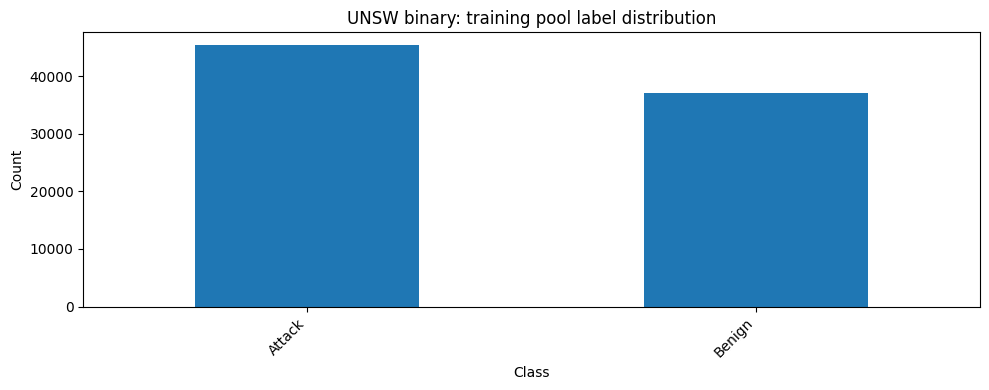

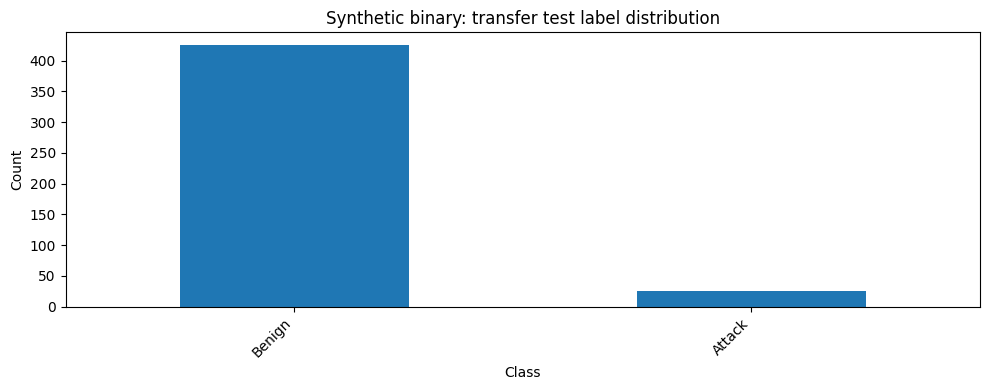

systems2024_arch1_1dcnn_seed_11 | epoch 01 | loss=0.2442 | val_acc=0.9419 | val_macro_f1=0.9416
systems2024_arch1_1dcnn_seed_11 | epoch 02 | loss=0.1393 | val_acc=0.9443 | val_macro_f1=0.9440
systems2024_arch1_1dcnn_seed_11 | epoch 03 | loss=0.1244 | val_acc=0.9528 | val_macro_f1=0.9526
systems2024_arch1_1dcnn_seed_11 | epoch 04 | loss=0.1145 | val_acc=0.9568 | val_macro_f1=0.9565
systems2024_arch1_1dcnn_seed_11 | epoch 05 | loss=0.1138 | val_acc=0.9567 | val_macro_f1=0.9564
systems2024_arch1_1dcnn_seed_11 | epoch 06 | loss=0.1112 | val_acc=0.9611 | val_macro_f1=0.9608
systems2024_arch1_1dcnn_seed_11 | epoch 07 | loss=0.1054 | val_acc=0.9582 | val_macro_f1=0.9580
systems2024_arch1_1dcnn_seed_11 | epoch 08 | loss=0.1060 | val_acc=0.9558 | val_macro_f1=0.9556
systems2024_arch1_1dcnn_seed_11 | epoch 09 | loss=0.1014 | val_acc=0.9600 | val_macro_f1=0.9597
systems2024_arch1_1dcnn_seed_11 | epoch 10 | loss=0.1024 | val_acc=0.9624 | val_macro_f1=0.9621
systems2024_arch1_1dcnn_seed_11 | epoch 

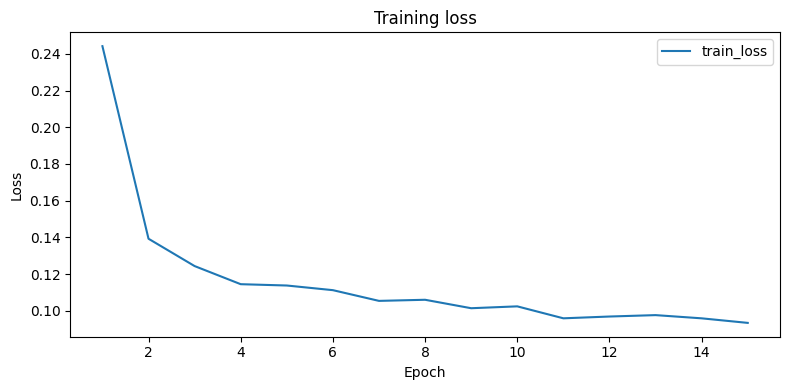

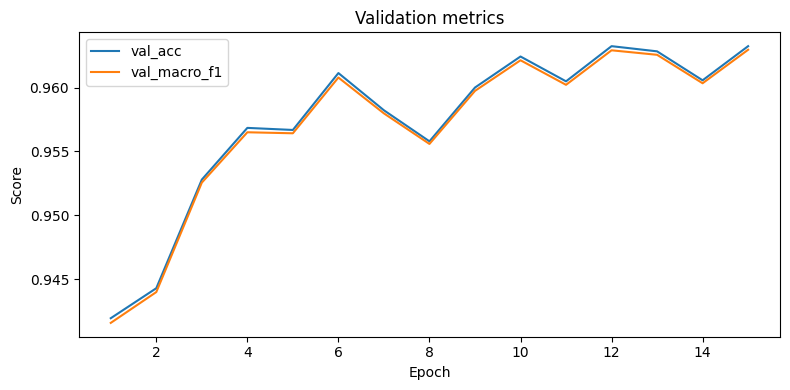

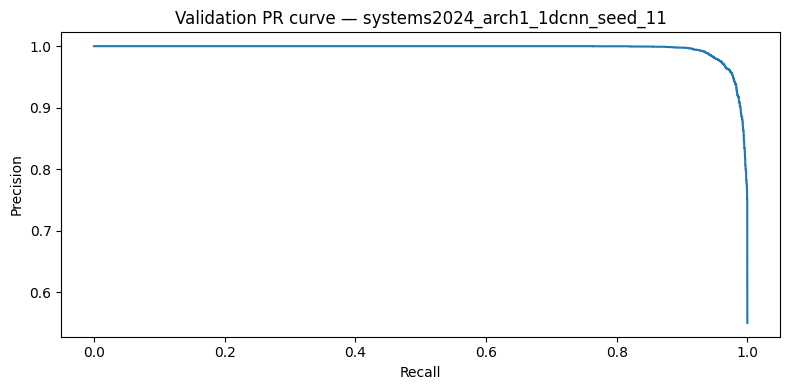

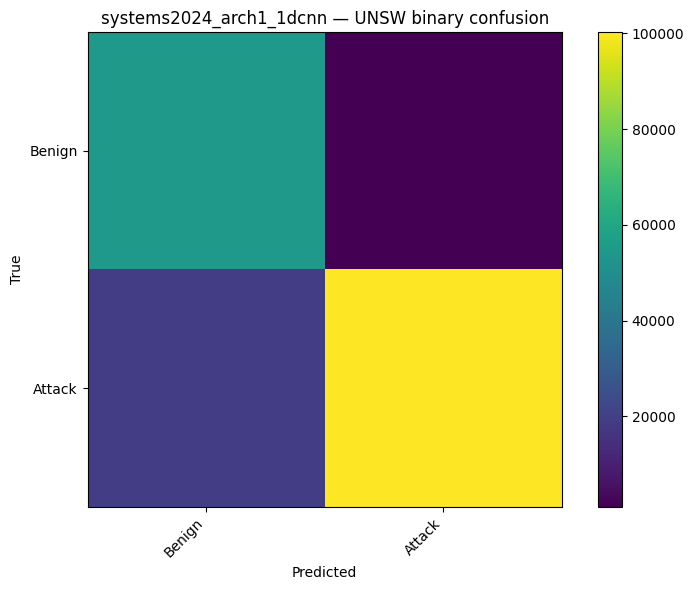

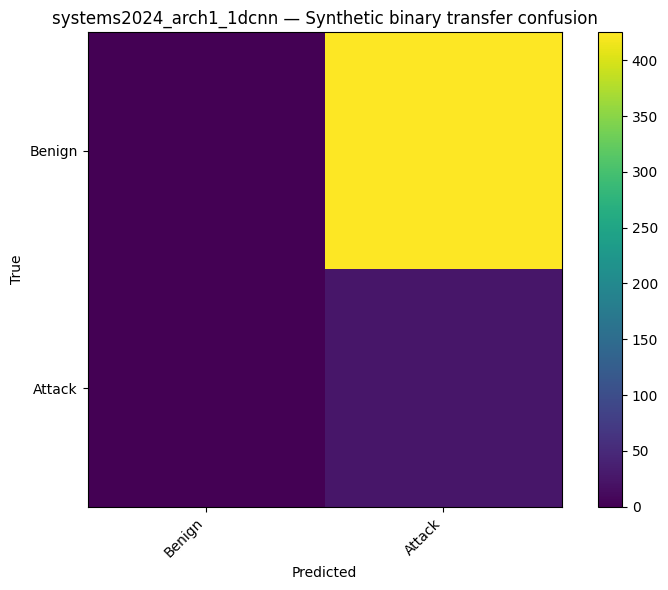

systems2024_arch1_1dcnn_seed_22 | epoch 01 | loss=0.2639 | val_acc=0.9389 | val_macro_f1=0.9379
systems2024_arch1_1dcnn_seed_22 | epoch 02 | loss=0.1431 | val_acc=0.9481 | val_macro_f1=0.9479
systems2024_arch1_1dcnn_seed_22 | epoch 03 | loss=0.1228 | val_acc=0.9521 | val_macro_f1=0.9518
systems2024_arch1_1dcnn_seed_22 | epoch 04 | loss=0.1179 | val_acc=0.9521 | val_macro_f1=0.9518
systems2024_arch1_1dcnn_seed_22 | epoch 05 | loss=0.1092 | val_acc=0.9588 | val_macro_f1=0.9585
systems2024_arch1_1dcnn_seed_22 | epoch 06 | loss=0.1096 | val_acc=0.9592 | val_macro_f1=0.9589
systems2024_arch1_1dcnn_seed_22 | epoch 07 | loss=0.1052 | val_acc=0.9543 | val_macro_f1=0.9540
systems2024_arch1_1dcnn_seed_22 | epoch 08 | loss=0.0998 | val_acc=0.9628 | val_macro_f1=0.9624
systems2024_arch1_1dcnn_seed_22 | epoch 09 | loss=0.0995 | val_acc=0.9608 | val_macro_f1=0.9605
systems2024_arch1_1dcnn_seed_22 | epoch 10 | loss=0.0979 | val_acc=0.9613 | val_macro_f1=0.9610
systems2024_arch1_1dcnn_seed_22 | epoch 

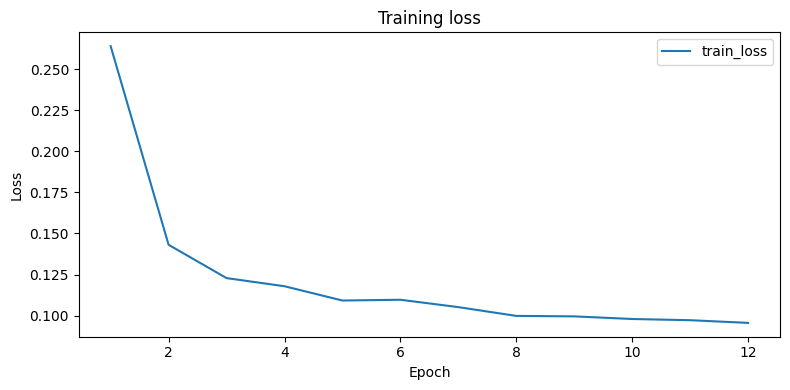

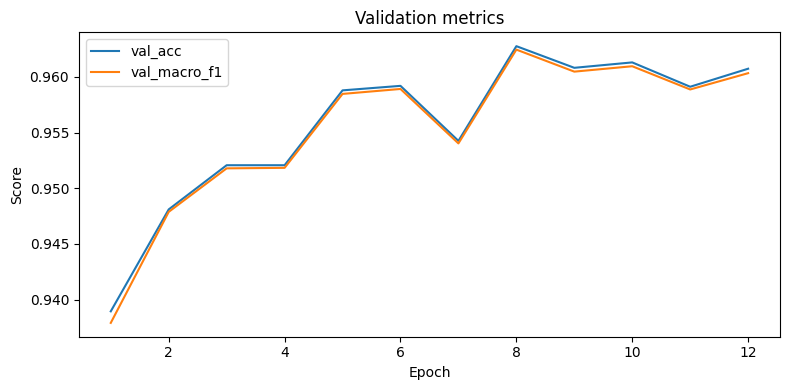

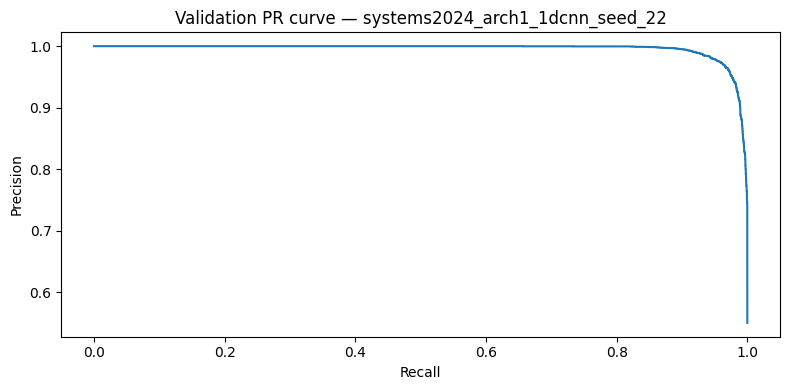

systems2024_arch1_1dcnn_seed_33 | epoch 01 | loss=0.2562 | val_acc=0.9303 | val_macro_f1=0.9301
systems2024_arch1_1dcnn_seed_33 | epoch 02 | loss=0.1421 | val_acc=0.9542 | val_macro_f1=0.9538
systems2024_arch1_1dcnn_seed_33 | epoch 03 | loss=0.1255 | val_acc=0.9564 | val_macro_f1=0.9560
systems2024_arch1_1dcnn_seed_33 | epoch 04 | loss=0.1167 | val_acc=0.9566 | val_macro_f1=0.9561
systems2024_arch1_1dcnn_seed_33 | epoch 05 | loss=0.1086 | val_acc=0.9549 | val_macro_f1=0.9546
systems2024_arch1_1dcnn_seed_33 | epoch 06 | loss=0.1123 | val_acc=0.9595 | val_macro_f1=0.9591
systems2024_arch1_1dcnn_seed_33 | epoch 07 | loss=0.1070 | val_acc=0.9585 | val_macro_f1=0.9581
systems2024_arch1_1dcnn_seed_33 | epoch 08 | loss=0.1040 | val_acc=0.9613 | val_macro_f1=0.9609
systems2024_arch1_1dcnn_seed_33 | epoch 09 | loss=0.1028 | val_acc=0.9633 | val_macro_f1=0.9630
systems2024_arch1_1dcnn_seed_33 | epoch 10 | loss=0.0984 | val_acc=0.9580 | val_macro_f1=0.9578
systems2024_arch1_1dcnn_seed_33 | epoch 

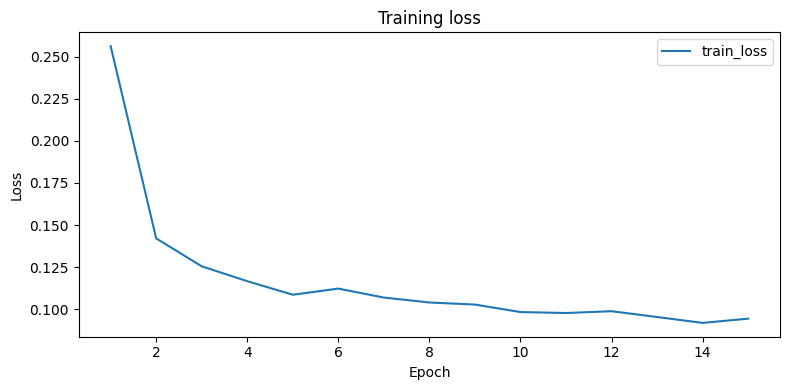

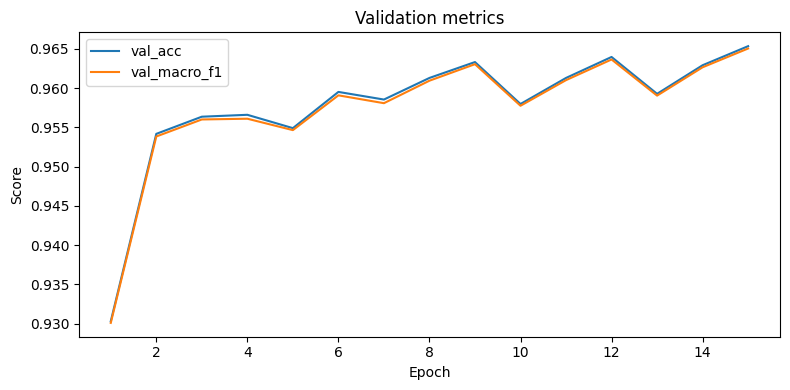

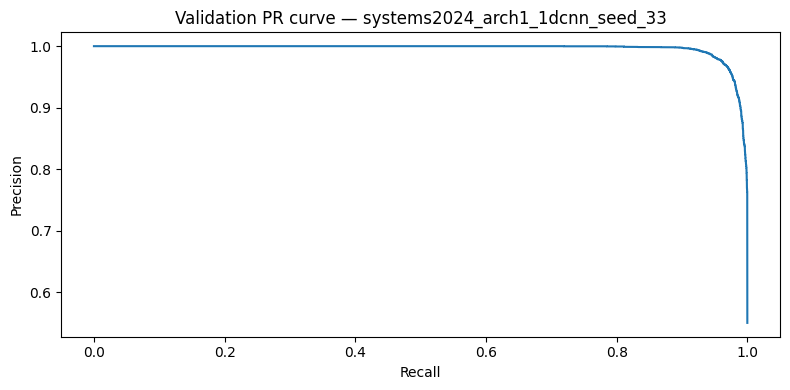

systems2024_arch1_1dcnn_seed_44 | epoch 01 | loss=0.2705 | val_acc=0.9343 | val_macro_f1=0.9335
systems2024_arch1_1dcnn_seed_44 | epoch 02 | loss=0.1475 | val_acc=0.9478 | val_macro_f1=0.9474
systems2024_arch1_1dcnn_seed_44 | epoch 03 | loss=0.1307 | val_acc=0.9488 | val_macro_f1=0.9486
systems2024_arch1_1dcnn_seed_44 | epoch 04 | loss=0.1153 | val_acc=0.9509 | val_macro_f1=0.9506
systems2024_arch1_1dcnn_seed_44 | epoch 05 | loss=0.1134 | val_acc=0.9568 | val_macro_f1=0.9565
systems2024_arch1_1dcnn_seed_44 | epoch 06 | loss=0.1115 | val_acc=0.9570 | val_macro_f1=0.9567
systems2024_arch1_1dcnn_seed_44 | epoch 07 | loss=0.1072 | val_acc=0.9532 | val_macro_f1=0.9530
systems2024_arch1_1dcnn_seed_44 | epoch 08 | loss=0.1051 | val_acc=0.9576 | val_macro_f1=0.9573
systems2024_arch1_1dcnn_seed_44 | epoch 09 | loss=0.1057 | val_acc=0.9529 | val_macro_f1=0.9525
systems2024_arch1_1dcnn_seed_44 | epoch 10 | loss=0.1021 | val_acc=0.9568 | val_macro_f1=0.9566
systems2024_arch1_1dcnn_seed_44 | epoch 

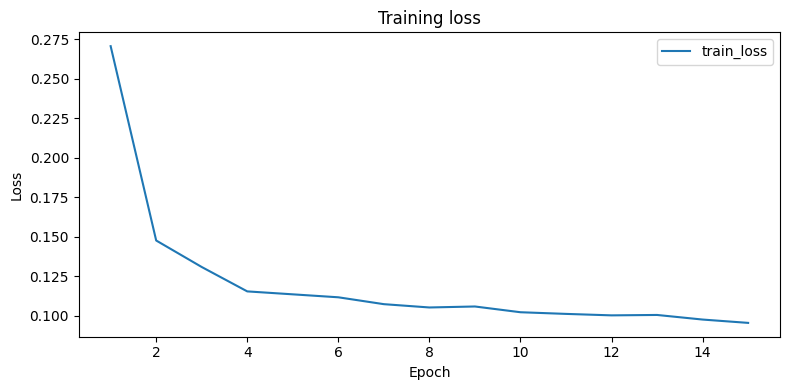

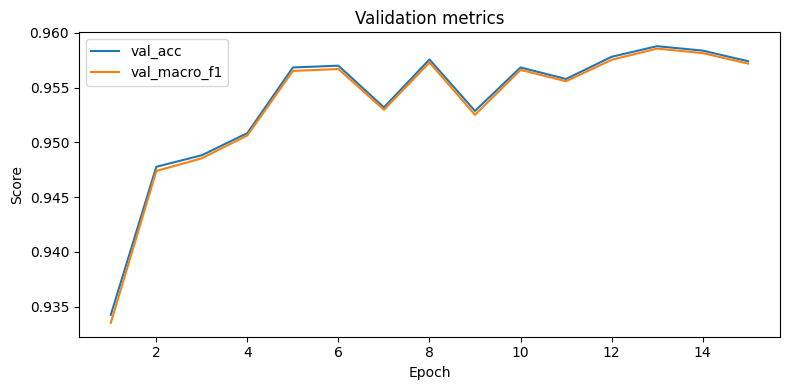

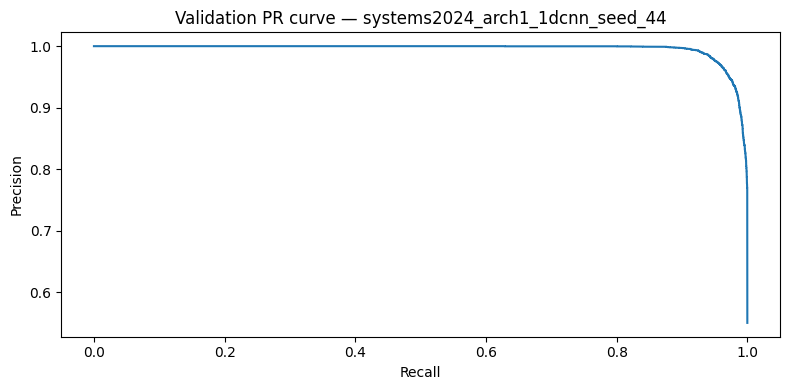

systems2024_arch1_1dcnn_seed_55 | epoch 01 | loss=0.2467 | val_acc=0.9425 | val_macro_f1=0.9421
systems2024_arch1_1dcnn_seed_55 | epoch 02 | loss=0.1336 | val_acc=0.9518 | val_macro_f1=0.9514
systems2024_arch1_1dcnn_seed_55 | epoch 03 | loss=0.1212 | val_acc=0.9582 | val_macro_f1=0.9580
systems2024_arch1_1dcnn_seed_55 | epoch 04 | loss=0.1144 | val_acc=0.9582 | val_macro_f1=0.9579
systems2024_arch1_1dcnn_seed_55 | epoch 05 | loss=0.1052 | val_acc=0.9617 | val_macro_f1=0.9614
systems2024_arch1_1dcnn_seed_55 | epoch 06 | loss=0.1071 | val_acc=0.9565 | val_macro_f1=0.9563
systems2024_arch1_1dcnn_seed_55 | epoch 07 | loss=0.1041 | val_acc=0.9616 | val_macro_f1=0.9613
systems2024_arch1_1dcnn_seed_55 | epoch 08 | loss=0.1039 | val_acc=0.9585 | val_macro_f1=0.9582
systems2024_arch1_1dcnn_seed_55 | epoch 09 | loss=0.1023 | val_acc=0.9619 | val_macro_f1=0.9615
systems2024_arch1_1dcnn_seed_55 | epoch 10 | loss=0.0973 | val_acc=0.9615 | val_macro_f1=0.9613
systems2024_arch1_1dcnn_seed_55 | epoch 

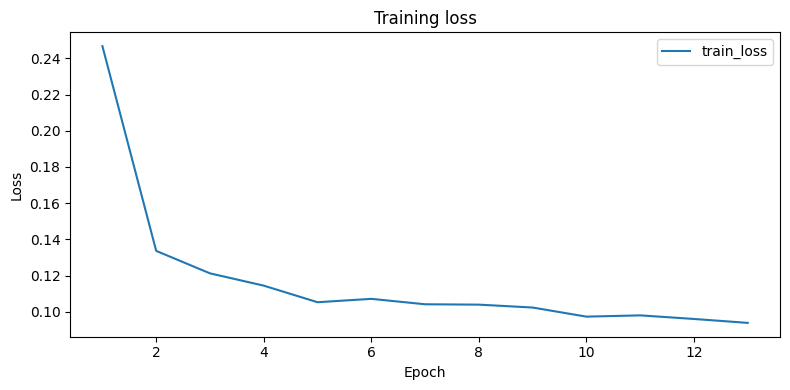

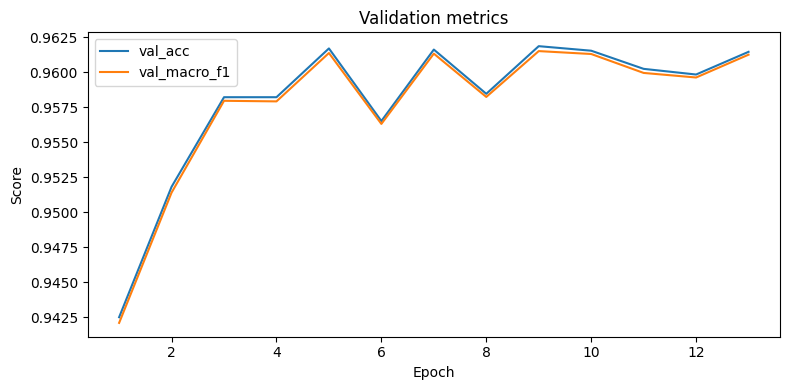

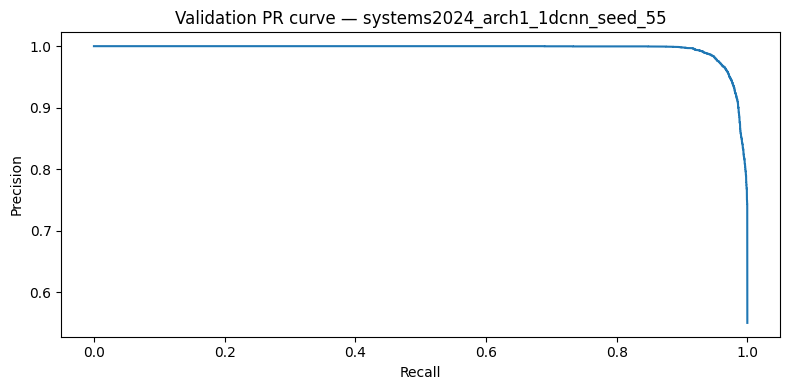

UNSW summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,systems2024_arch1_1dcnn,0.88601,0.004998,0.988465,0.001571,0.842363,0.008734,0.909559,0.004476


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch1_1dcnn,0.055556,0.0,0.055556,0.0,1.0,0.0,0.105263,0.0,450.0,450.0


Running: systems2024_arch2_1dcnn | task: binary


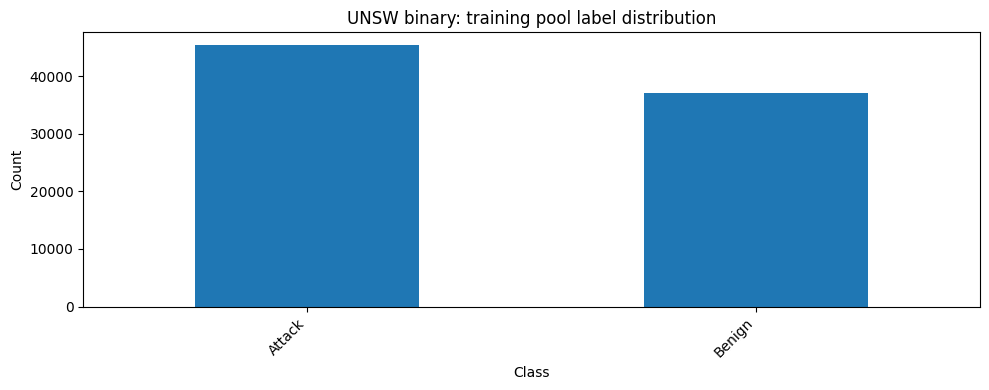

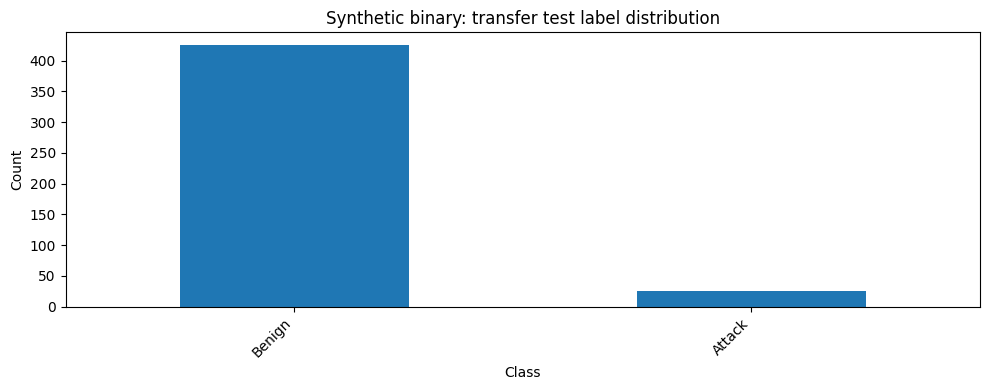

systems2024_arch2_1dcnn_seed_11 | epoch 01 | loss=0.2377 | val_acc=0.9499 | val_macro_f1=0.9495
systems2024_arch2_1dcnn_seed_11 | epoch 02 | loss=0.1338 | val_acc=0.9543 | val_macro_f1=0.9537
systems2024_arch2_1dcnn_seed_11 | epoch 03 | loss=0.1199 | val_acc=0.9582 | val_macro_f1=0.9579
systems2024_arch2_1dcnn_seed_11 | epoch 04 | loss=0.1084 | val_acc=0.9591 | val_macro_f1=0.9589
systems2024_arch2_1dcnn_seed_11 | epoch 05 | loss=0.1095 | val_acc=0.9490 | val_macro_f1=0.9488
systems2024_arch2_1dcnn_seed_11 | epoch 06 | loss=0.1054 | val_acc=0.9607 | val_macro_f1=0.9603
systems2024_arch2_1dcnn_seed_11 | epoch 07 | loss=0.1025 | val_acc=0.9615 | val_macro_f1=0.9611
systems2024_arch2_1dcnn_seed_11 | epoch 08 | loss=0.1017 | val_acc=0.9615 | val_macro_f1=0.9612
systems2024_arch2_1dcnn_seed_11 | epoch 09 | loss=0.0982 | val_acc=0.9601 | val_macro_f1=0.9599
systems2024_arch2_1dcnn_seed_11 | epoch 10 | loss=0.0991 | val_acc=0.9548 | val_macro_f1=0.9546
systems2024_arch2_1dcnn_seed_11 | epoch 

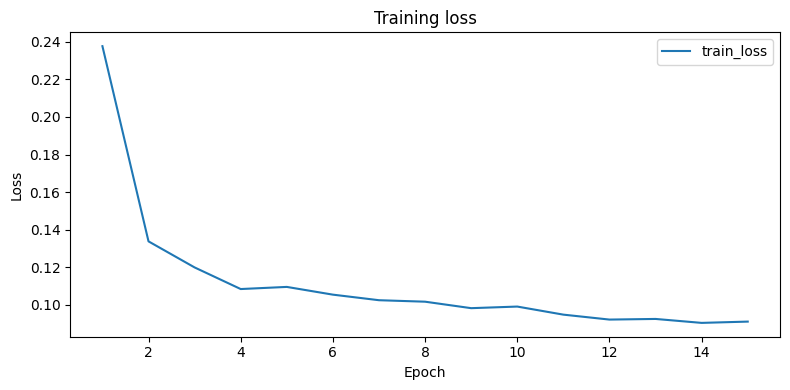

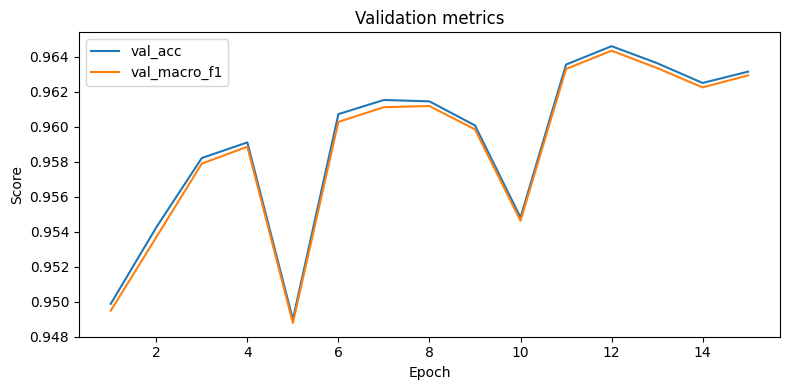

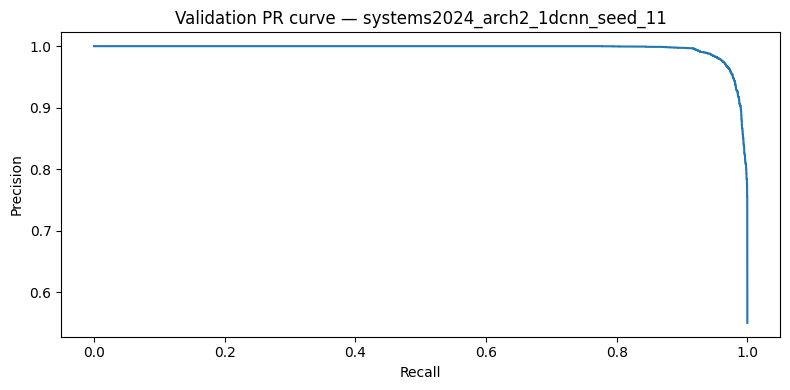

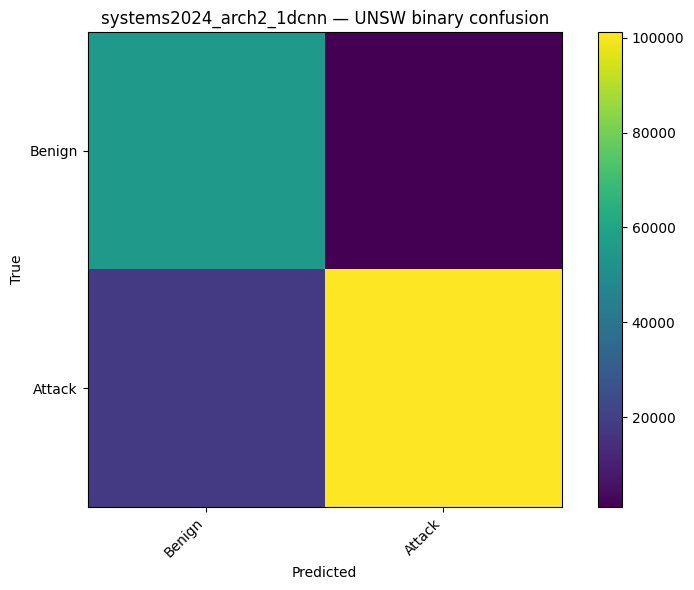

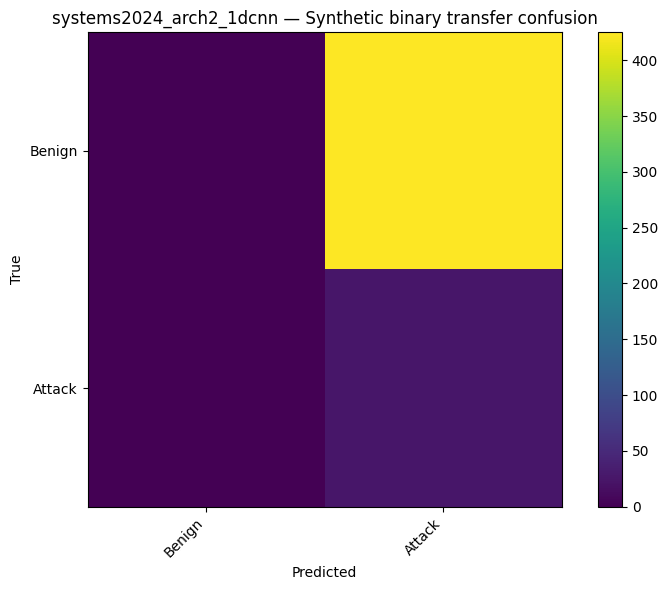

systems2024_arch2_1dcnn_seed_22 | epoch 01 | loss=0.2539 | val_acc=0.9292 | val_macro_f1=0.9291
systems2024_arch2_1dcnn_seed_22 | epoch 02 | loss=0.1370 | val_acc=0.9500 | val_macro_f1=0.9497
systems2024_arch2_1dcnn_seed_22 | epoch 03 | loss=0.1207 | val_acc=0.9539 | val_macro_f1=0.9536
systems2024_arch2_1dcnn_seed_22 | epoch 04 | loss=0.1129 | val_acc=0.9580 | val_macro_f1=0.9577
systems2024_arch2_1dcnn_seed_22 | epoch 05 | loss=0.1058 | val_acc=0.9583 | val_macro_f1=0.9579
systems2024_arch2_1dcnn_seed_22 | epoch 06 | loss=0.1059 | val_acc=0.9501 | val_macro_f1=0.9500
systems2024_arch2_1dcnn_seed_22 | epoch 07 | loss=0.1026 | val_acc=0.9590 | val_macro_f1=0.9587
systems2024_arch2_1dcnn_seed_22 | epoch 08 | loss=0.0975 | val_acc=0.9615 | val_macro_f1=0.9611
systems2024_arch2_1dcnn_seed_22 | epoch 09 | loss=0.0978 | val_acc=0.9598 | val_macro_f1=0.9596
systems2024_arch2_1dcnn_seed_22 | epoch 10 | loss=0.0963 | val_acc=0.9609 | val_macro_f1=0.9606
systems2024_arch2_1dcnn_seed_22 | epoch 

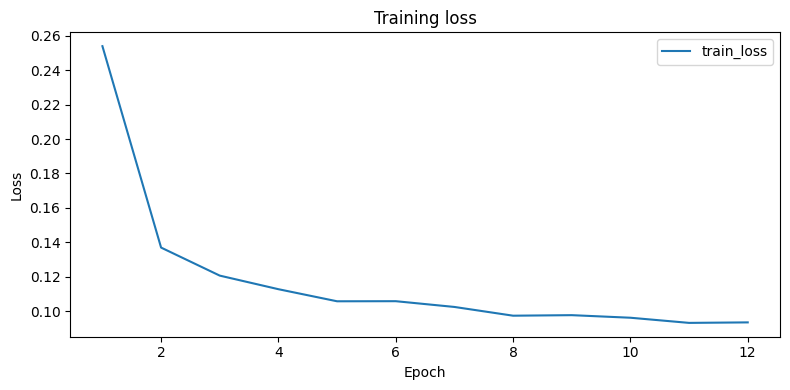

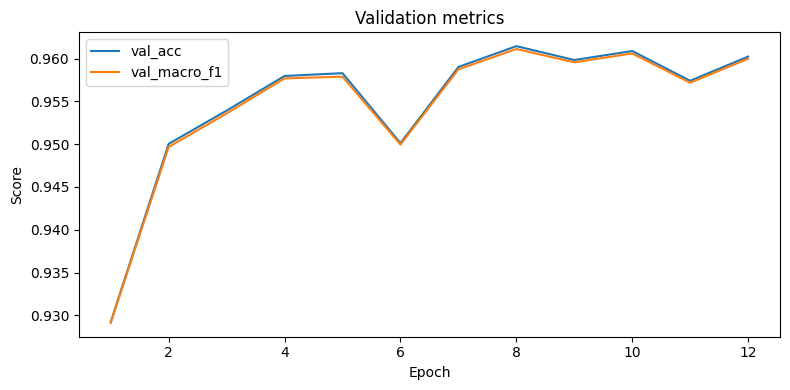

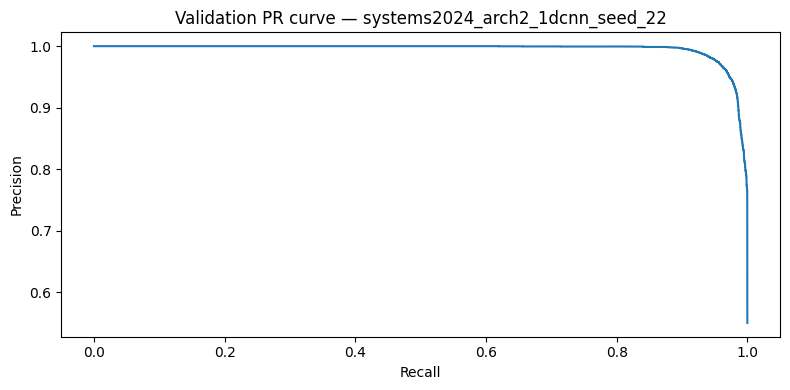

systems2024_arch2_1dcnn_seed_33 | epoch 01 | loss=0.2510 | val_acc=0.9356 | val_macro_f1=0.9354
systems2024_arch2_1dcnn_seed_33 | epoch 02 | loss=0.1356 | val_acc=0.9508 | val_macro_f1=0.9501
systems2024_arch2_1dcnn_seed_33 | epoch 03 | loss=0.1202 | val_acc=0.9568 | val_macro_f1=0.9564
systems2024_arch2_1dcnn_seed_33 | epoch 04 | loss=0.1117 | val_acc=0.9538 | val_macro_f1=0.9536
systems2024_arch2_1dcnn_seed_33 | epoch 05 | loss=0.1064 | val_acc=0.9576 | val_macro_f1=0.9573
systems2024_arch2_1dcnn_seed_33 | epoch 06 | loss=0.1081 | val_acc=0.9592 | val_macro_f1=0.9589
systems2024_arch2_1dcnn_seed_33 | epoch 07 | loss=0.1045 | val_acc=0.9638 | val_macro_f1=0.9635
systems2024_arch2_1dcnn_seed_33 | epoch 08 | loss=0.0996 | val_acc=0.9605 | val_macro_f1=0.9602
systems2024_arch2_1dcnn_seed_33 | epoch 09 | loss=0.0990 | val_acc=0.9625 | val_macro_f1=0.9622
systems2024_arch2_1dcnn_seed_33 | epoch 10 | loss=0.0961 | val_acc=0.9612 | val_macro_f1=0.9610
systems2024_arch2_1dcnn_seed_33 | epoch 

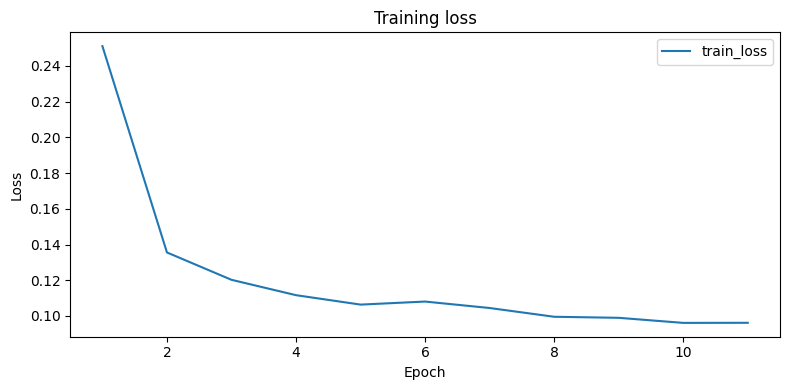

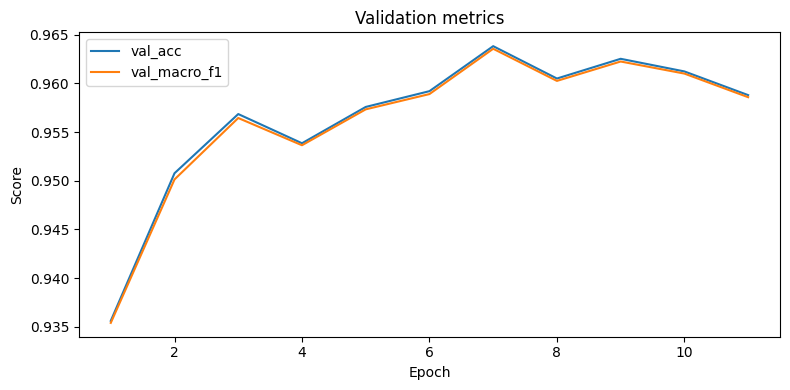

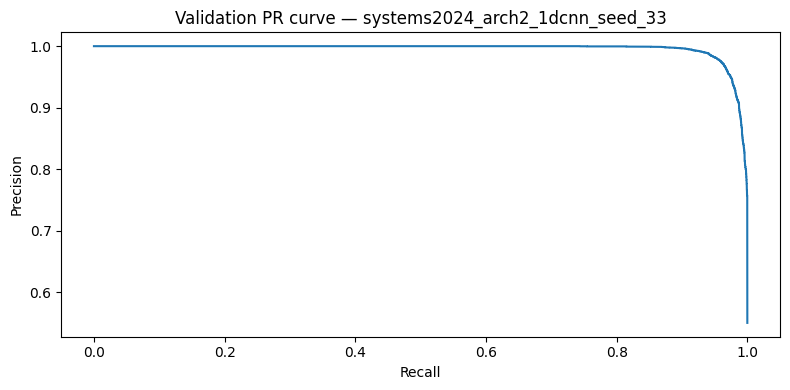

systems2024_arch2_1dcnn_seed_44 | epoch 01 | loss=0.2553 | val_acc=0.9420 | val_macro_f1=0.9416
systems2024_arch2_1dcnn_seed_44 | epoch 02 | loss=0.1366 | val_acc=0.9400 | val_macro_f1=0.9399
systems2024_arch2_1dcnn_seed_44 | epoch 03 | loss=0.1216 | val_acc=0.9485 | val_macro_f1=0.9482
systems2024_arch2_1dcnn_seed_44 | epoch 04 | loss=0.1137 | val_acc=0.9529 | val_macro_f1=0.9527
systems2024_arch2_1dcnn_seed_44 | epoch 05 | loss=0.1067 | val_acc=0.9558 | val_macro_f1=0.9556
systems2024_arch2_1dcnn_seed_44 | epoch 06 | loss=0.1044 | val_acc=0.9512 | val_macro_f1=0.9509
systems2024_arch2_1dcnn_seed_44 | epoch 07 | loss=0.1019 | val_acc=0.9558 | val_macro_f1=0.9556
systems2024_arch2_1dcnn_seed_44 | epoch 08 | loss=0.0985 | val_acc=0.9570 | val_macro_f1=0.9568
systems2024_arch2_1dcnn_seed_44 | epoch 09 | loss=0.0977 | val_acc=0.9597 | val_macro_f1=0.9594
systems2024_arch2_1dcnn_seed_44 | epoch 10 | loss=0.0961 | val_acc=0.9589 | val_macro_f1=0.9586
systems2024_arch2_1dcnn_seed_44 | epoch 

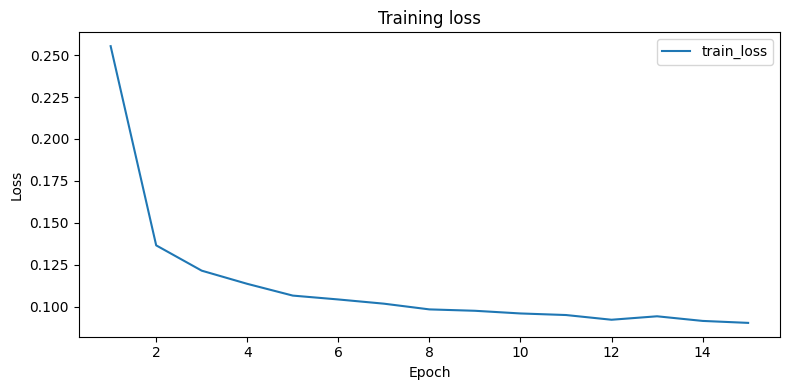

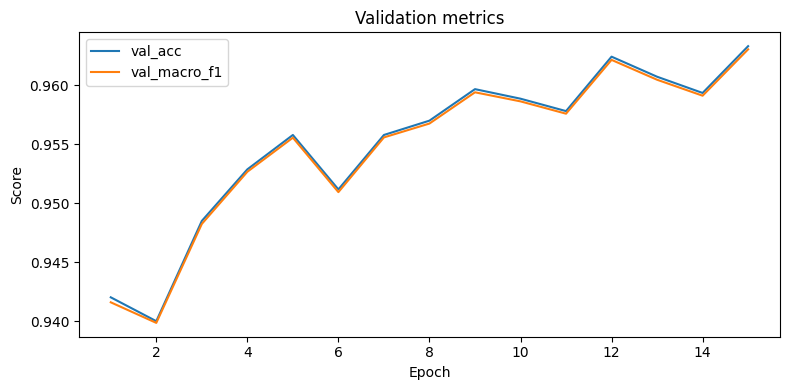

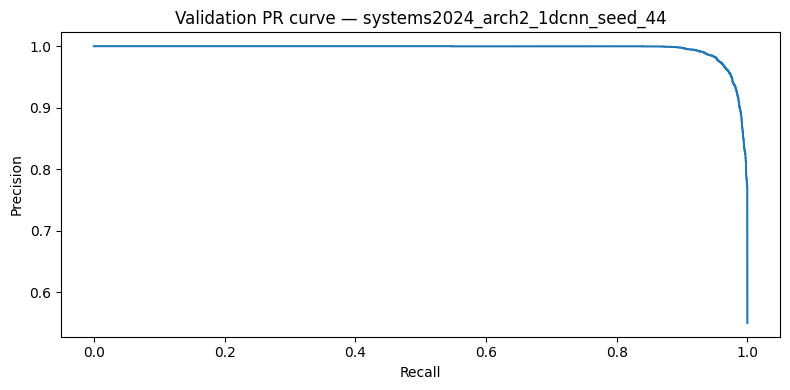

systems2024_arch2_1dcnn_seed_55 | epoch 01 | loss=0.2602 | val_acc=0.9439 | val_macro_f1=0.9436
systems2024_arch2_1dcnn_seed_55 | epoch 02 | loss=0.1338 | val_acc=0.9531 | val_macro_f1=0.9527
systems2024_arch2_1dcnn_seed_55 | epoch 03 | loss=0.1185 | val_acc=0.9558 | val_macro_f1=0.9556
systems2024_arch2_1dcnn_seed_55 | epoch 04 | loss=0.1159 | val_acc=0.9605 | val_macro_f1=0.9602
systems2024_arch2_1dcnn_seed_55 | epoch 05 | loss=0.1049 | val_acc=0.9568 | val_macro_f1=0.9566
systems2024_arch2_1dcnn_seed_55 | epoch 06 | loss=0.1046 | val_acc=0.9615 | val_macro_f1=0.9612
systems2024_arch2_1dcnn_seed_55 | epoch 07 | loss=0.1022 | val_acc=0.9618 | val_macro_f1=0.9615
systems2024_arch2_1dcnn_seed_55 | epoch 08 | loss=0.1027 | val_acc=0.9600 | val_macro_f1=0.9598
systems2024_arch2_1dcnn_seed_55 | epoch 09 | loss=0.0991 | val_acc=0.9645 | val_macro_f1=0.9643
systems2024_arch2_1dcnn_seed_55 | epoch 10 | loss=0.0986 | val_acc=0.9611 | val_macro_f1=0.9609
systems2024_arch2_1dcnn_seed_55 | epoch 

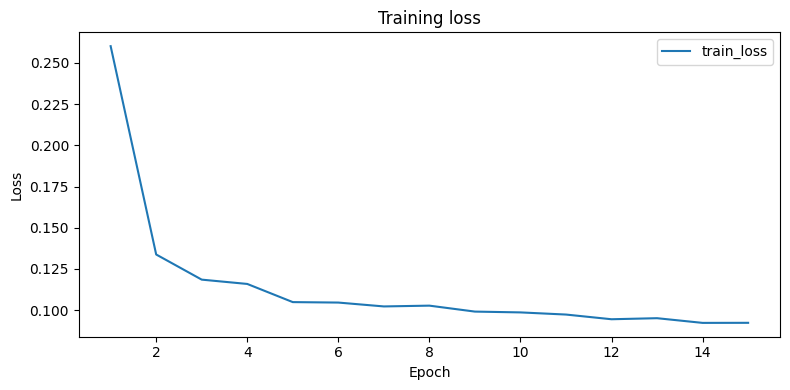

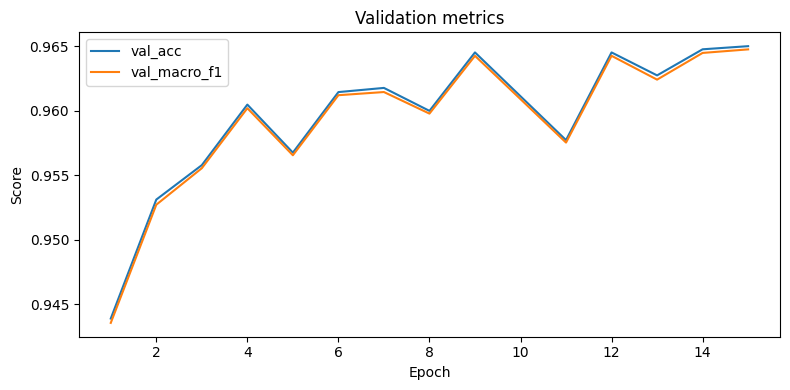

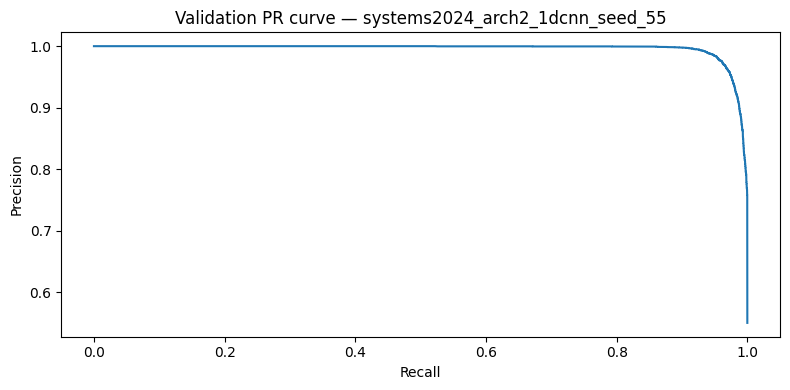

UNSW summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,systems2024_arch2_1dcnn,0.886424,0.003073,0.989369,0.000977,0.84218,0.004795,0.909853,0.002687


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch2_1dcnn,0.055556,0.0,0.055556,0.0,1.0,0.0,0.105263,0.0,450.0,450.0


Running: noever2021_mobilenetv2_image | task: binary


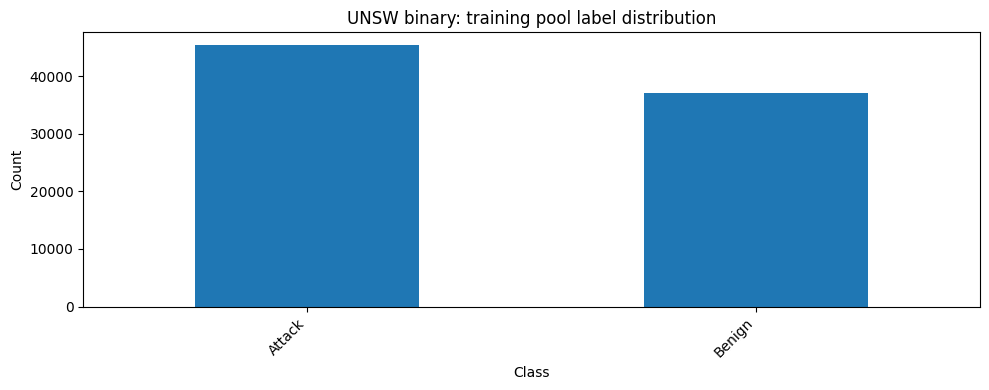

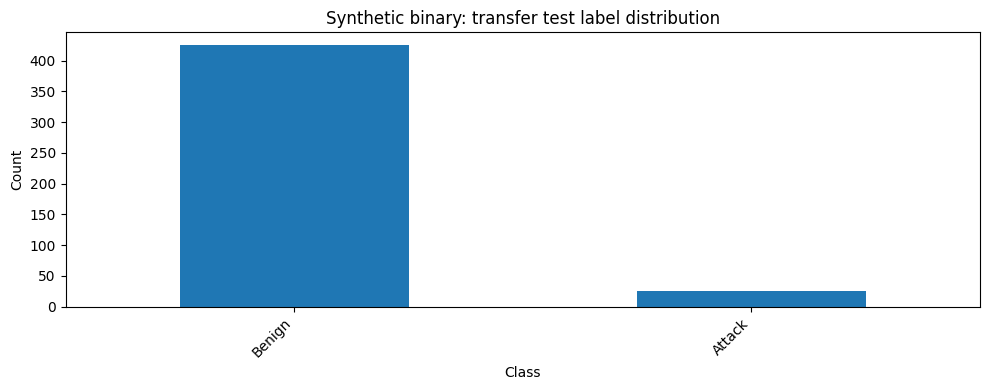

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


noever2021_mobilenetv2_image_seed_11 | epoch 01 | loss=0.1946 | val_acc=0.9280 | val_macro_f1=0.9269
noever2021_mobilenetv2_image_seed_11 | epoch 02 | loss=0.1397 | val_acc=0.9355 | val_macro_f1=0.9353
noever2021_mobilenetv2_image_seed_11 | epoch 03 | loss=0.1213 | val_acc=0.9190 | val_macro_f1=0.9190
noever2021_mobilenetv2_image_seed_11 | epoch 04 | loss=0.1097 | val_acc=0.9594 | val_macro_f1=0.9591
noever2021_mobilenetv2_image_seed_11 | epoch 05 | loss=0.1088 | val_acc=0.9542 | val_macro_f1=0.9539
noever2021_mobilenetv2_image_seed_11 | epoch 06 | loss=0.1043 | val_acc=0.9568 | val_macro_f1=0.9566
noever2021_mobilenetv2_image_seed_11 | epoch 07 | loss=0.0992 | val_acc=0.9598 | val_macro_f1=0.9596
noever2021_mobilenetv2_image_seed_11 | epoch 08 | loss=0.1002 | val_acc=0.9517 | val_macro_f1=0.9514
noever2021_mobilenetv2_image_seed_11 | epoch 09 | loss=0.1005 | val_acc=0.9584 | val_macro_f1=0.9582
noever2021_mobilenetv2_image_seed_11 | epoch 10 | loss=0.0960 | val_acc=0.9585 | val_macro_

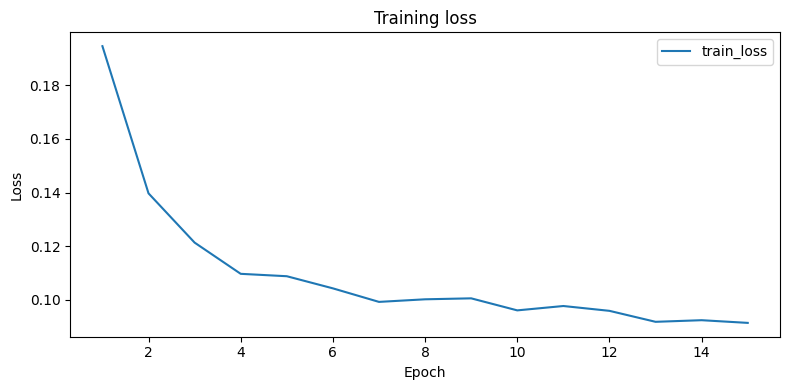

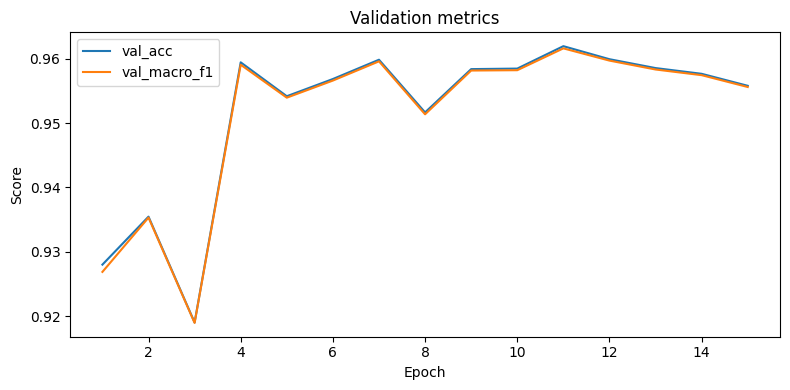

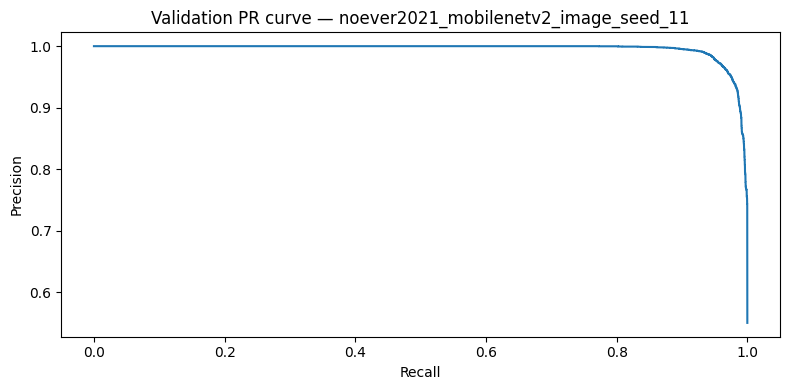

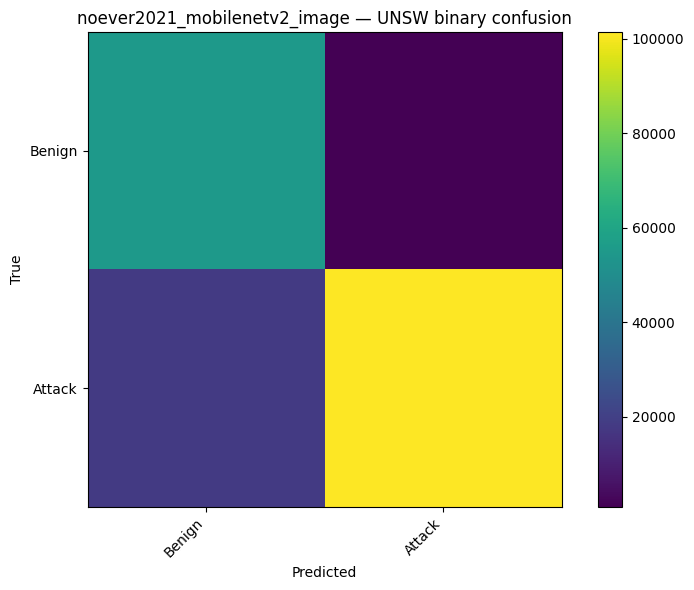

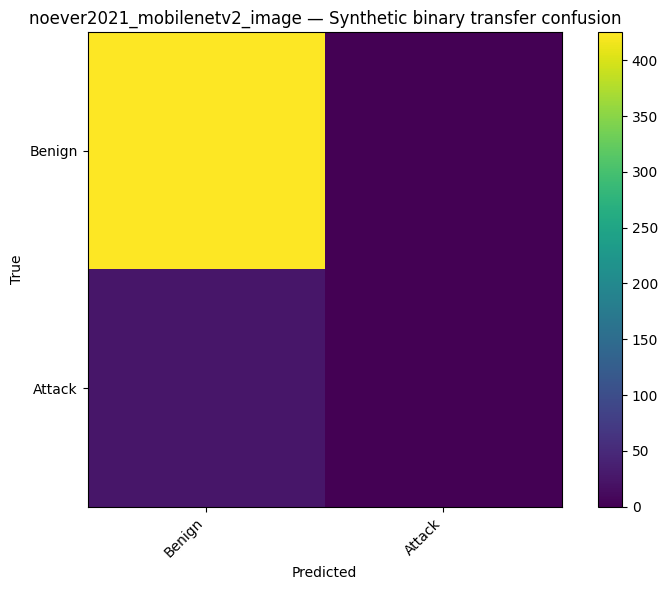

In [ ]:
results = {}

for task in ["binary", "multiclass"]:
    results[task] = {}
    for model_name in MODEL_NAMES:
        print("=" * 80)
        print("Running:", model_name, "| task:", task)
        unsw_runs_df, unsw_summary, syn_runs_df, syn_summary = run_model_for_task(model_name, task)
        results[task][model_name] = {
            "unsw_runs": unsw_runs_df,
            "unsw_summary": unsw_summary,
            "synthetic_runs": syn_runs_df,
            "synthetic_summary": syn_summary,
        }
        print("UNSW summary")
        display(unsw_summary)
        print("Synthetic transfer summary")
        display(syn_summary)


## Combined Comparison Tables


In [ ]:
unsw_rows = []
syn_rows = []
drop_rows = []
paper_rows = []

for task in ["binary", "multiclass"]:
    for model_name in MODEL_NAMES:
        us = results[task][model_name]["unsw_summary"].copy()
        sy = results[task][model_name]["synthetic_summary"].copy()

        us["task"] = task
        us["model"] = model_name
        sy["task"] = task
        sy["model"] = model_name

        unsw_rows.append(us)
        syn_rows.append(sy)

        if task == "binary":
            drop_rows.append({
                "task": task,
                "model": model_name,
                "unsw_accuracy_mean": float(us.iloc[0]["accuracy_mean"]),
                "synthetic_accuracy_mean": float(sy.iloc[0]["accuracy_mean"]),
                "accuracy_drop": float(us.iloc[0]["accuracy_mean"] - sy.iloc[0]["accuracy_mean"]),
                "unsw_f1_mean": float(us.iloc[0]["f1_mean"]),
                "synthetic_f1_mean": float(sy.iloc[0]["f1_mean"]),
                "f1_drop": float(us.iloc[0]["f1_mean"] - sy.iloc[0]["f1_mean"]),
            })
        else:
            drop_rows.append({
                "task": task,
                "model": model_name,
                "unsw_accuracy_mean": float(us.iloc[0]["accuracy_mean"]),
                "synthetic_accuracy_mean": float(sy.iloc[0]["accuracy_mean"]),
                "accuracy_drop": float(us.iloc[0]["accuracy_mean"] - sy.iloc[0]["accuracy_mean"]),
                "unsw_macro_f1_mean": float(us.iloc[0]["macro_f1_mean"]),
                "synthetic_macro_f1_mean": float(sy.iloc[0]["macro_f1_mean"]),
                "macro_f1_drop": float(us.iloc[0]["macro_f1_mean"] - sy.iloc[0]["macro_f1_mean"]),
            })

        p = OUT_ROOT / "unsw" / task / model_name / "tables" / "paper_vs_reproduced.csv"
        if p.exists():
            paper_rows.append(pd.read_csv(p))

unsw_cmp = pd.concat(unsw_rows, ignore_index=True)
syn_cmp = pd.concat(syn_rows, ignore_index=True)
drop_df = pd.DataFrame(drop_rows)
paper_df = pd.concat(paper_rows, ignore_index=True) if len(paper_rows) > 0 else pd.DataFrame()

unsw_cmp.to_csv(OUT_ROOT / "combined" / "unsw_benchmark_cnn_comparison.csv", index=False)
syn_cmp.to_csv(OUT_ROOT / "combined" / "synthetic_transfer_cnn_comparison.csv", index=False)
drop_df.to_csv(OUT_ROOT / "combined" / "unsw_to_synthetic_drop_analysis.csv", index=False)
if not paper_df.empty:
    paper_df.to_csv(OUT_ROOT / "combined" / "paper_vs_reproduced_all.csv", index=False)

print("UNSW benchmark comparison")
display(unsw_cmp)

print("Synthetic transfer comparison")
display(syn_cmp)

print("Drop analysis")
display(drop_df)

if not paper_df.empty:
    print("Paper vs reproduced")
    display(paper_df)


## Artifact Dashboard


In [ ]:
def list_files(folder):
    return sorted([p.name for p in folder.glob("*")])

dashboard = {}

for root_name, root_path in {
    "unsw": OUT_ROOT / "unsw",
    "synthetic_transfer": OUT_ROOT / "synthetic_transfer",
}.items():
    dashboard[root_name] = {}
    for task in ["binary", "multiclass"]:
        dashboard[root_name][task] = {}
        for model_name in MODEL_NAMES:
            model_dir = root_path / task / model_name
            dashboard[root_name][task][model_name] = {
                "tables": list_files(model_dir / "tables"),
                "figures": list_files(model_dir / "figures"),
                "metrics": list_files(model_dir / "metrics"),
                "reports": list_files(model_dir / "reports"),
                "models": list_files(model_dir / "models"),
            }

dashboard["combined"] = list_files(OUT_ROOT / "combined")
save_json(dashboard, OUT_ROOT / "combined" / "artefact_dashboard.json")
dashboard


## Result Summary Export


In [ ]:
lines = []
lines.append("# Benchmark CNN Results Summary")
lines.append("")
lines.append("## Completed")
lines.append("- systems2024_arch1_1dcnn on UNSW binary and multiclass")
lines.append("- systems2024_arch2_1dcnn on UNSW binary and multiclass")
lines.append("- noever2021_mobilenetv2_image on UNSW binary and multiclass")
lines.append("- Synthetic transfer evaluation for all three benchmark CNN methods")
lines.append("")
lines.append("## Main result files")
lines.append("- combined/unsw_benchmark_cnn_comparison.csv")
lines.append("- combined/synthetic_transfer_cnn_comparison.csv")
lines.append("- combined/unsw_to_synthetic_drop_analysis.csv")
lines.append("- combined/paper_vs_reproduced_all.csv")
lines.append("")
lines.append("## How to use these in the thesis")
lines.append("- Use UNSW tables to show benchmark CNN performance against published methods.")
lines.append("- Use paper-vs-reproduced tables to explain where accuracy changed.")
lines.append("- Use synthetic transfer tables to discuss domain shift and generalization.")
lines.append("")
summary_path = OUT_ROOT / "combined" / "benchmark_cnn_summary.md"
save_text("\n".join(lines), summary_path)
print("Saved:", summary_path.resolve())
